# Multiprocessing and Functional Programming
# Srbuhi Khachatryan

In [2]:
!pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool, cpu_count
from functools import reduce
import math

In [3]:
data = yf.download("AAPL", period="1y")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-02-28,240.790543,241.039458,229.201054,235.921763,56833400
2025-03-03,236.997086,242.971049,235.085419,240.740764,47184000
2025-03-04,234.906158,239.028207,233.661583,236.678448,53798100
2025-03-05,234.717010,235.523493,228.235251,234.398392,47227600
2025-03-06,234.308777,236.827797,232.148195,233.422640,45170400


In [4]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

table = pd.read_html(response.text)[0]
tickers = table["Symbol"].tolist()

tickers[:10]

C:\Users\User\AppData\Local\Temp\ipykernel_10732\3862497504.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)[0]


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [5]:
def download_stock(ticker, period="1y"):
    return yf.download(ticker, period=period, progress=False)

start = time.time()

single_data = {}
for t in tickers[:50]:
    single_data[t] = download_stock(t)

single_time = time.time() - start
single_time

17.193395137786865

In [6]:
start = time.time()

multi_data = yf.download(
    tickers[:50],
    period="1y",
    group_by="ticker",
    threads=True   # built-in threading
)

multi_time = time.time() - start
multi_time

[*********************100%***********************]  50 of 50 completed


1.6426115036010742

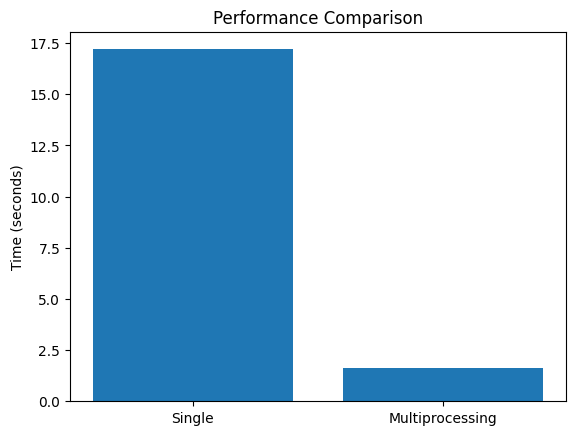

In [7]:
plt.bar(["Single", "Multiprocessing"], [single_time, multi_time])
plt.ylabel("Time (seconds)")
plt.title("Performance Comparison")
plt.show()

In [8]:
ls = [1,2,3,4,5,6,7,8,9]

In [9]:
squared = list(map(lambda x: x**2, ls))
squared

[1, 4, 9, 16, 25, 36, 49, 64, 81]

In [10]:
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(math.sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True

primes = list(filter(is_prime, ls))
primes

[2, 3, 5, 7]

In [11]:
sum_sq = reduce(lambda x, y: x + y, squared)
sum_sq

285

In [12]:
target = 5
mse = reduce(lambda acc, x: acc + (x-target)**2, ls, 0) / len(ls)
mse

6.666666666666667

In [13]:
df = pd.DataFrame({"values": ls})

df["squared"] = df["values"].apply(lambda x: x**2)
df["is_prime"] = df["values"].apply(lambda x: is_prime(x))

df

,values,squared,is_prime
0,1,1,False
1,2,4,True
2,3,9,True
3,4,16,False
4,5,25,True
5,6,36,False
6,7,49,True
7,8,64,False
8,9,81,False


In [14]:
text = "data science is fun and data science is powerful"
words = text.split()

In [15]:
mapped = list(map(lambda w: (w,1), words))
mapped

[('data', 1),
 ('science', 1),
 ('is', 1),
 ('fun', 1),
 ('and', 1),
 ('data', 1),
 ('science', 1),
 ('is', 1),
 ('powerful', 1)]

In [16]:
from collections import defaultdict

def reducer(mapped_data):
    counts = defaultdict(int)
    for word, count in mapped_data:
        counts[word] += count
    return counts

word_counts = reducer(mapped)

In [17]:
sorted_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
sorted_counts

[('data', 2),
 ('science', 2),
 ('is', 2),
 ('fun', 1),
 ('and', 1),
 ('powerful', 1)]